# Predict


In [5]:
import geopandas as gpd
import geoutils as gu
import numpy as np
import rasterio as rio
import pandas as pd
from pathlib import Path

import xdem

import subkart

In [2]:
RESOLUTION = 50
crs = "EPSG:25833"


In [11]:
classifier = subkart.utils.load_classifier()

# Predict for Norge

In [4]:
REGIONS = {
    "vestland": ["More_og_Romsdal", "Vestland", "Rogaland"],
    "sor-ost": ["Agder", "Telemark", "Vestfold", "Ostfold", "Akershus", "Buskerud", "Oslo"],
    "midt": ["Trondelag", "Nordland"],
    "nord": ["Troms", "Finnmark"],
}

## Marine Vanntyper

In [5]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(crs)
marine_vanntyper = subkart.features.marine_vanntyper_preprocess(marine_vanntyper)


## DEM 50

In [6]:
dem_norge = xdem.DEM(rio.open("https://storage.googleapis.com/niva-geodata/MarintNaturKart/dem50_norge.tif"))

## Predict

In [ ]:
nodata = 255
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
for region_name, region_list in REGIONS.items():
    print(f"Processing region: {region_name}")
    gdf_sea_map_region = subkart.sources.sea_map_basisdata(region_list)
    gdf_sea_map_region = subkart.features.depth_preprocess(gdf_sea_map_region)
    transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map_region, res=RESOLUTION)
    marine_vanntyper_region = marine_vanntyper.cx[bounds[0] : bounds[2], bounds[1] : bounds[3]]
    dem_region = subkart.utils.resample_dem(dem_norge.crop(bounds), out_shape, transform, crs)

    X, valid_attrs, out_shape, transform = subkart.features.build(
        dem_region, gdf_sea_map_region, marine_vanntyper_region, valid_mask=None, res=RESOLUTION, dtype=np.float16
    )
    print("Predict ...")
    Y_pred = classifier.predict(X)

    pred_map = np.full(out_shape, nodata, dtype=np.uint8)
    pred_map[valid_attrs] = Y_pred.astype(np.uint8)

    # Mask nodata values explicitly to avoid the warning
    pred_map_masked = np.ma.masked_equal(pred_map, nodata)

    pred_raster = gu.Raster.from_array(pred_map_masked, transform=transform, crs=crs, nodata=nodata)
    fname = f"{region_name}_prediction.tif"
    pred_raster.to_file(Path(fname))
    print(f"Saved prediction for region {region_name} to {fname}\n")


Processing region: vestland


In [3]:
%%bash

gdal_merge.py -o norge_merged.tif -n 255 -a_nodata 255 -of GTiff \
  -co COMPRESS=DEFLATE -co TILED=YES \
  *_prediction.tif

0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:05.


In [ ]:
%%bash
rm mask*.tif labels.tif
# 1) Build masks for 0, 1, 2 (NoData=255)
gdal_calc.py -A norge_merged.tif --outfile=mask0.tif --NoDataValue=255 --type=Byte --calc="(A==0)" --overwrite
gdal_calc.py -A norge_merged.tif --outfile=mask1.tif --NoDataValue=255 --type=Byte --calc="(A==1)" --overwrite
gdal_calc.py -A norge_merged.tif --outfile=mask2.tif --NoDataValue=255 --type=Byte --calc="(A==2)" --overwrite

# 2) Optional: de-speckle each mask (threshold in pixels; e.g., 16 px ≈ 40,000 m²)
gdal_sieve.py -st 16 -8 mask0.tif mask0_sieved.tif 
gdal_sieve.py -st 16 -8 mask1.tif mask1_sieved.tif 
gdal_sieve.py -st 16 -8 mask2.tif mask2_sieved.tif 

# 4) Recombine by priority (2 > 1 > 0) into a single labeled raster
#    Note: (B) mask2, (C) mask1, (D) mask0; ensure masks are 0/1
gdal_calc.py -A mask2_sieved.tif -B mask1_sieved.tif -C mask0_sieved.tif \
  --outfile=labels.tif --type=Byte --NoDataValue=255 \
  --calc="where(A==1, 2, where((A==0)*(B==1), 1, where((A==0)*(B==0)*(C==1), 0, 255)))" 

# 5) Polygonize exclusive labels (0,1,2) — attribute 'DN'
gdal_polygonize.py labels.tif -f GPKG polygons_raw.gpkg polys DN 

# 6) Light vector simplify (optional) 
ogr2ogr polygons_exclusive.gpkg polygons_raw.gpkg -nln polys -simplify 25

rm mask*.tif labels.tif

0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:11.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:10.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:10.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:10.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:09.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:10.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:19.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:15.


In [27]:
gdf_raw = gpd.read_file("polygons_raw.gpkg")

In [32]:
fname = subkart.utils.to_filename(
    f"nisjedata-substrat-{classifier.__class__.__name__.lower()}", "norge", "latest", gdf_raw.crs.to_epsg()
)
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
gdf_raw["BunnType"] = gdf_raw["DN"].map(reverse_map)
gdf_raw.to_file(f"{fname}.geojson", driver="GeoJSON")
gdf_raw.to_file(f"{fname}.gpkg", driver="GPKG", layer="bunntyper")
subkart.utils.to_postgis(gdf_raw, fname)

Table nisjedata-substrat-xgbclassifier_norge_latest uploaded to PostGIS.


# Predict for AOI

In [31]:
gdf_sea_map = subkart.sources.sea_map_basisdata(["More_og_Romsdal"])
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)
crs = gdf_sea_map.crs

In [32]:
gdf_sea_map_more = subkart.features.depth_preprocess(gdf_sea_map)

All depth features already present, skipping preprocessing.


In [33]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(gdf_sea_map.crs)
marine_vanntyper = subkart.features.marine_vanntyper_preprocess(marine_vanntyper)
minx, miny, maxx, maxy = gdf_sea_map.total_bounds
marine_vanntyper = marine_vanntyper.cx[minx:maxx, miny:maxy]

In [34]:
gdf_bunn_moere = gpd.read_file(
    "https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson"
)
gdf_clip = gdf_bunn_moere.to_crs(gdf_sea_map_more.crs)

vec_clip = gu.Vector(gdf_clip)

In [35]:
clipped_marine_vanntyper = gdf_clip.overlay(marine_vanntyper)

In [36]:
clipped_gdf = gdf_clip.overlay(gdf_sea_map_more)

In [37]:
transform, out_shape, bounds = subkart.features.to_raster_shapes(clipped_gdf, res=RESOLUTION)
dem = xdem.DEM(rio.open("https://storage.googleapis.com/niva-geodata/MarintNaturKart/dem50_vestland.tif"))
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)

In [38]:
X, valid_attrs, out_shape, transform = subkart.features.build(
    dem, clipped_gdf, clipped_marine_vanntyper, valid_mask=None, res=RESOLUTION, dtype=np.float16
)

Processing avg_depth...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing avg_slope...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing compactness...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing convexity...


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Processing marine types...
Stacking feature arrays...


In [39]:
Y_pred = classifier.predict(X)

In [40]:
pred_map = np.full(out_shape, np.nan, dtype=np.float32)
pred_map[valid_attrs] = Y_pred.astype(np.float32)

In [41]:
pred_raster = gu.Raster.from_array(pred_map, transform=transform, crs=crs)

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


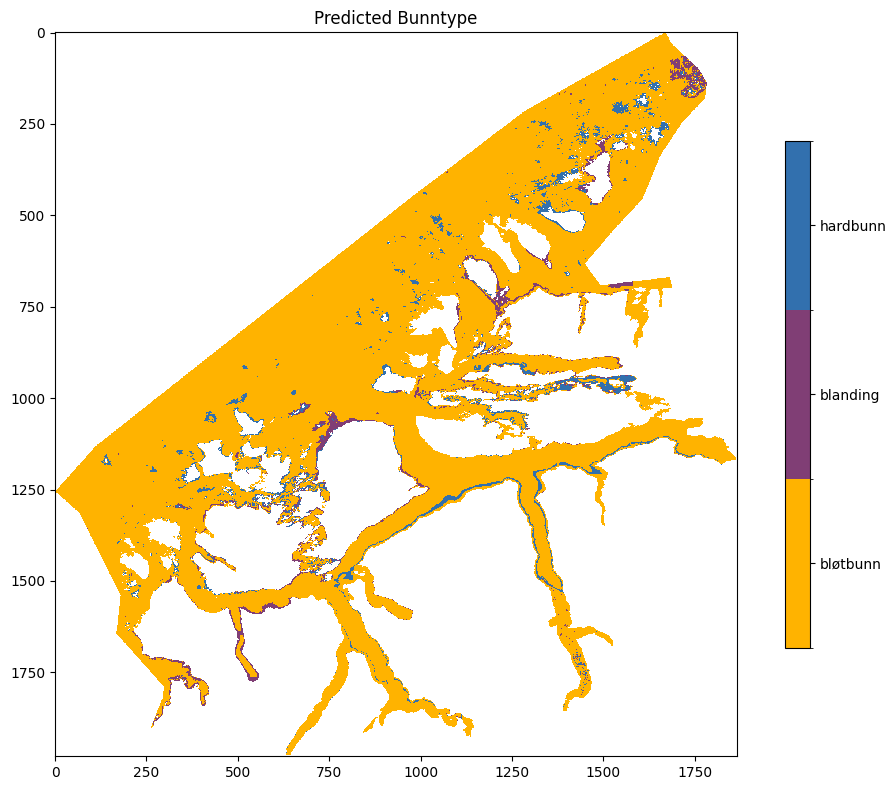

In [42]:
subkart.utils.plot_prediction_raster(pred_raster)

# Vectorize output

In [43]:
pred_vec = pred_raster.polygonize()

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/interface/raster_vector.py:102: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


In [ ]:
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

0         løsbunn
1        fastbunn
2        blanding
3         løsbunn
4         løsbunn
           ...   
10053     løsbunn
10054    fastbunn
10055    fastbunn
10056    fastbunn
10057    fastbunn
Name: BunnType, Length: 10058, dtype: object

In [ ]:
gdf_final = pred_vec.ds.to_crs("EPSG:25833")
fname = subkart.utils.to_filename(
    f"nisjedata-substrat-{classifier.__class__.__name__.lower()}", "aoi-moere-og-romsdal", "latest", gdf_final.crs.to_epsg()
)
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")